<font size="5">Collab Specific Imports: </font>

In [ ]:
# !pip install -q -U transformers peft accelerate datasets torchao tqdm
# import sys
# from google.colab import drive

# drive.mount('/content/drive')
# sys.path.append('/content/drive/MyDrive/final-project')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<font size="5">Library and File Imports:</font>

In [ ]:
import torch
import matplotlib.pyplot as plt
# from google.colab import drive, files
from accelerate import Accelerator
from peft import PeftModel
from transformers import get_cosine_schedule_with_warmup, AutoModelForCausalLM
from models.model_builder import load_sft_model_and_tokenizer, load_dpo_model_and_tokenizer
from data.data_loader import load_sft_data, load_dpo_data
from training.dpo import train_dpo, test_dpo
from training.sft import train_sft, test_sft
from utils.visualize import plot_dpo_metrics, plot_sft_metrics
from utils.inference import generate_and_print_example_outputs


<font size="5">Load SFT model and tokenizer and SFT data: </font>

In [3]:
sft_model, sft_tokenizer = load_sft_model_and_tokenizer()
sft_train_dataloader, sft_test_dataloader, sft_test_sample = load_sft_data(sft_tokenizer, 10) # optionally adjust batch size here (default is 4)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [4]:
print(sft_model.device)

cuda:0


<font size="5">Set up parameters for training and perform supervised finetuning on the model: </font>

In [5]:
# optimizer, scheduler, epochs, accelerator
epochs = 1
lr = 2e-4
weight_decay = 0.01
accelerator = Accelerator(gradient_accumulation_steps=3, mixed_precision="fp16")
optimizer = torch.optim.AdamW(params=[p for p in sft_model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)

total_updates = (len(sft_train_dataloader) // accelerator.gradient_accumulation_steps) * epochs
warmup_steps = int(0.1 * total_updates)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_updates)

sft_model, optimizer, sft_train_dataloader, scheduler = accelerator.prepare(sft_model, optimizer, sft_train_dataloader, scheduler)

sft_step_losses = train_sft(sft_model, sft_train_dataloader, optimizer, scheduler, accelerator, epochs)

DPO Epoch 1/1:   0%|          | 0/6114 [00:00<?, ?it/s]

Average epoch loss for epoch 0 : 1.412366267879843


<font size="5"> Test and experiment with the sft network : </font>

SFT Test Accuracy: 0.6446132075471698
SFT Test Loss: 1.397405144572258
SFT Test Perplexity: 4.04469108581543


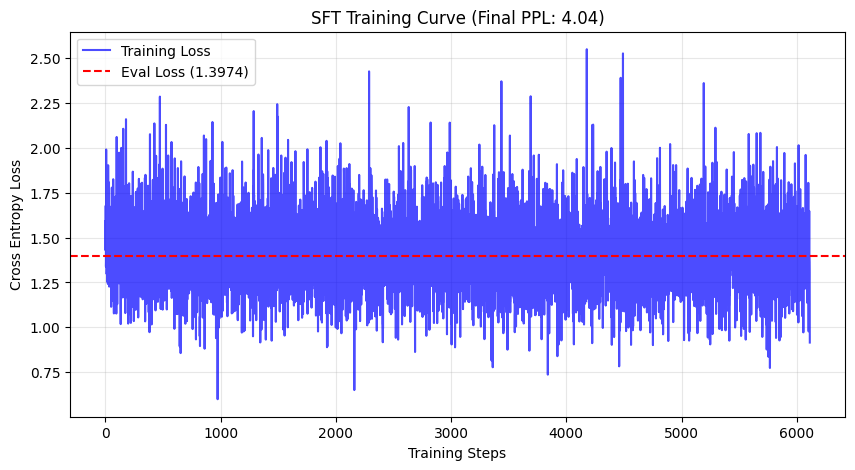

PROMPT:
Write an investigative report on the state of homelessness in America.

MODEL OUTPUT:
Title: The State of Homelessness in America: A Comprehensive Analysis

Introduction

Homelessness is a pervasive issue in the United States, affecting millions of people each year. Despite the country's commitment to

PROMPT:
A factory produces two types of toys: robots and cars. The factory can produce 50 robots and 100 cars per day. The demand for robots is represented by the equation p = 10 - 0.05q, where p is the price in dollars and q is the quantity demanded. The demand for cars is represented by the equation p = 15 - 0.1q.
What is the equilibrium price and quantity for each toy? How would a decrease in the cost of production affect the equilibrium price and quantity for each toy? Show your calculations and explain the concept behind the changes in equilibrium.

MODEL OUTPUT:
To find the equilibrium price and quantity for each toy, we need to set up the following equations:

1. For robot

In [6]:
# Calculate Test Metrics
sft_test_accuracy, sft_test_loss, sft_test_perplexity = test_sft(sft_model, sft_test_dataloader)
print(f"SFT Test Accuracy: {sft_test_accuracy}")
print(f"SFT Test Loss: {sft_test_loss}")
print(f"SFT Test Perplexity: {sft_test_perplexity}")

# Visualize training with final test metrics
plot_sft_metrics(sft_step_losses, sft_test_loss, sft_test_perplexity)

# Generate example input/outputs
generate_and_print_example_outputs(sft_model, sft_tokenizer, sft_test_sample)

<font size="5">Save the finetuned model : </font>

In [7]:
accelerator.wait_for_everyone()
unwrapped_sft_model = accelerator.unwrap_model(sft_model)
unwrapped_sft_model.save_pretrained('sft_adapter')
sft_tokenizer.save_pretrained('sft_adapter')
print("successfully saved sft adapter and tokenizer")

print("loading base model and integrating with sft adapter")
base_model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2-0.5B', torch_dtype=torch.bfloat16, device_map='auto')
sft_peft_model = PeftModel.from_pretrained(base_model, 'sft_adapter')
merged_model = sft_peft_model.merge_and_unload()
merged_model.save_pretrained('merged_sft_model')
sft_tokenizer.save_pretrained('merged_sft_model')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


successfully saved sft adapter and tokenizer
loading base model and integrating with sft adapter


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('merged_sft_model/tokenizer_config.json',
 'merged_sft_model/chat_template.jinja',
 'merged_sft_model/tokenizer.json')

Clear Cache so don't run into out of memory issues:

In [3]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Copy the folders into mounted Drive
# !cp -r sft_adapter /content/drive/MyDrive/final-project/
# !cp -r merged_sft_model /content/drive/MyDrive/final-project/

<font size="5">Load in the dpo model and data :</font>

In [3]:
print("Loading DPO model")
dpo_model, dpo_tokenizer = load_dpo_model_and_tokenizer('merged_sft_model')
dpo_train_dataloader, dpo_test_dataloader, dpo_test_sample = load_dpo_data(dpo_tokenizer, 5) # batch size defaults to 2

Loading DPO model


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


<font size="5">Set up hyperparameters and train the dpo model : </font>

In [4]:
dpo_epochs = 1
dpo_lr = 1e-5
dpo_beta = 0.1
dpo_weight_decay = 0.01
dpo_accelerator = Accelerator(gradient_accumulation_steps=6, mixed_precision='fp16')
dpo_optimizer = torch.optim.AdamW([p for p in dpo_model.parameters() if p.requires_grad], dpo_lr, weight_decay=dpo_weight_decay)

dpo_total_updates = (len(dpo_train_dataloader) // dpo_accelerator.gradient_accumulation_steps) * dpo_epochs
dpo_warmup_steps = int(0.1 * dpo_total_updates)
dpo_scheduler = get_cosine_schedule_with_warmup(dpo_optimizer, dpo_warmup_steps, dpo_total_updates)

dpo_model, dpo_optimizer, dpo_train_dataloader, dpo_scheduler = dpo_accelerator.prepare(dpo_model, dpo_optimizer, dpo_train_dataloader, dpo_scheduler)
dpo_step_losses, dpo_step_rewards = train_dpo(dpo_model, dpo_train_dataloader, dpo_optimizer, dpo_scheduler, dpo_accelerator, dpo_beta, dpo_epochs)

DPO Epoch 1/1:   0%|          | 0/12227 [00:00<?, ?it/s]

Average epoch loss for epoch 0 : 0.6432746284443057


<font size="5"> Test and experiment with DPO </font>

DPO Testing:   0%|          | 0/400 [00:00<?, ?it/s]

DPO test accuracy : 0.5445000126212836
DPO test loss: 0.6260578994452953


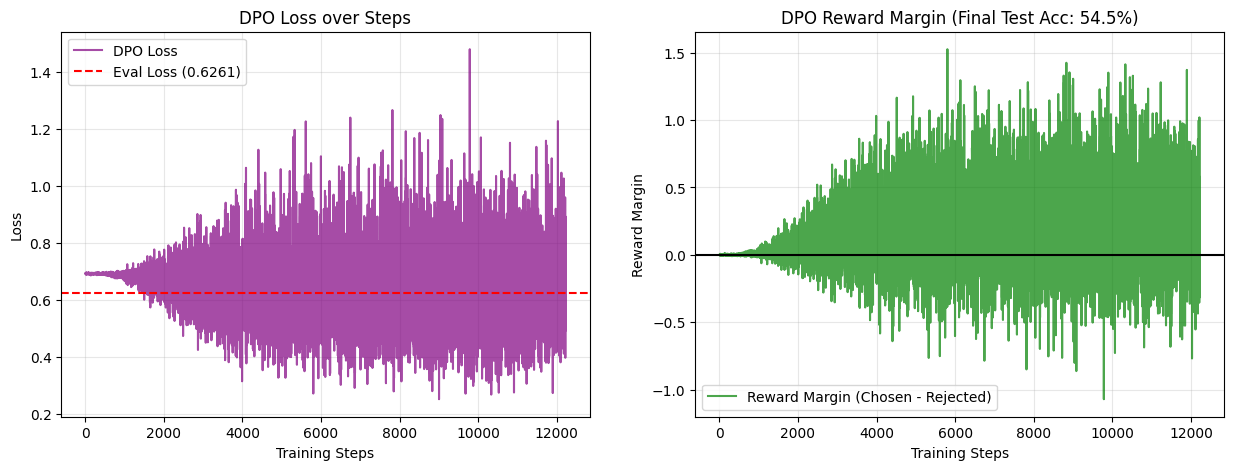

PROMPT:
Write an investigative report on the state of homelessness in America.

MODEL OUTPUT:
Title: The State of Homelessness in America: A Comprehensive Analysis

Introduction

Homelessness is a pervasive issue in the United States, affecting millions of individuals each year. Despite the country's commitment to

PROMPT:
A factory produces two types of toys: robots and cars. The factory can produce 50 robots and 100 cars per day. The demand for robots is represented by the equation p = 10 - 0.05q, where p is the price in dollars and q is the quantity demanded. The demand for cars is represented by the equation p = 15 - 0.1q.
What is the equilibrium price and quantity for each toy? How would a decrease in the cost of production affect the equilibrium price and quantity for each toy? Show your calculations and explain the concept behind the changes in equilibrium.

MODEL OUTPUT:
Let's first find the equilibrium prices and quantities for each toy:

1. Equilibrium price for robots:
The f

In [5]:
# Calculate Test Metrics
dpo_test_accuracy, dpo_test_loss = test_dpo(dpo_model, dpo_test_dataloader)
print(f"DPO test accuracy : {dpo_test_accuracy}")
print(f"DPO test loss: {dpo_test_loss}")

# Visualize training with final test metrics
plot_dpo_metrics(dpo_step_losses, dpo_step_rewards, dpo_test_accuracy, dpo_test_loss)

# Generate example input/outputs
generate_and_print_example_outputs(dpo_model, dpo_tokenizer, dpo_test_sample)

<font size="5"> Save the Trained DPO Adapters </font>

In [6]:
dpo_accelerator.wait_for_everyone()
unwrapped_dpo_model = dpo_accelerator.unwrap_model(dpo_model)
unwrapped_dpo_model.save_pretrained('dpo_adapter')
dpo_tokenizer.save_pretrained('dpo_adapter')
print("successfully saved dpo adapter and tokenizer")

successfully saved dpo adapter and tokenizer


In [ ]:
# !cp -r dpo_adapter /content/drive/MyDrive/final-project/